# Zero-Shot Classification of Crisis-Related News for Forecasting Flight Cancellations

**Team Members:** Rishiv Bawa, Gaurav Sharma, Veekshith Sumanth  
**Research Question:** Can Zero-Shot Classification applied to crisis-related news headlines predict international flight cancellations?  
**Hypothesis:** Zero-Shot Classification techniques can identify news articles containing crisis-related indicators with ≥70% precision when validated against actual recorded flight cancellation surges in public aviation datasets.

## Pipeline Overview
- **Stage 1:** Raw Data (GDELT crisis events + Flight cancellation records)
- **Stage 2:** Filtered & Classified (Zero-shot disruption labels, sentiment, temporal aggregation, community detection)
- **Stage 3:** Actionable Intelligence (Correlation analysis, predictive patterns, lead-time forecasting)

---
## STAGE 1: RAW DATA COLLECTION
### 3.1 Data Collection (Methodology)

In [ ]:
# =========================
# Install Required Libraries
# =========================
# Check CUDA availability
!nvcc --version

print("\n✓ GPU detected - will use for Phi-3.5 Mini acceleration")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Install PyTorch and Transformers for Phi-3.5 Mini
print("Installing transformers library for Phi-3.5 Mini...")
!pip install -q transformers torch accelerate

print("\n✓ Transformers installed successfully")
print("Note: Phi-3.5 Mini (3.8B) will auto-download from HuggingFace on first run (~7.5GB)")
print("Model will be cached for subsequent runs")

In [ ]:
# Core data science libraries
!pip install -q pandas numpy matplotlib seaborn

# Additional ML libraries for clustering and embeddings
!pip install -q sentence-transformers scikit-learn networkx python-louvain

print("✓ All required packages installed")

In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully")
print(f"Random seed set to: {RANDOM_SEED}")

Libraries imported successfully
Random seed set to: 42


### Data Source 1: GDELT Crisis Events

**Methodology (3.1):**
- **Source:** GDELT Events 2.0 database (https://www.gdeltproject.org/)
- **File:** `gdelt_crisis_aviation_clean.csv` (pre-filtered dataset)
- **Time Period:** January 2024 - December 2024
- **Records:** ~11,113 aviation-related crisis events
- **File Size:** ~5MB (optimized for Google Colab upload)
- **Selection Criteria:** Events filtered by CAMEO crisis codes (14=Protest, 17=Coerce, 18=Assault, 19=Fight, 20=Mass Violence) AND aviation-related keywords
- **Pre-filtering:** Dataset was pre-filtered from ~30 million global GDELT events to only aviation-related crisis events
- **Justification:** GDELT provides structured, timestamped event data from global news sources, enabling temporal correlation analysis. Using pre-filtered data eliminates need for large file processing in Google Colab.

In [ ]:
# Load pre-filtered GDELT crisis-aviation events
# File: gdelt_crisis_aviation_clean.csv (~5MB, 11,113 aviation crisis events from 2024)

print("Loading pre-filtered GDELT crisis events...")
print("File: gdelt_crisis_aviation_clean.csv")
print("Note: This file contains only aviation-related crisis events from 2024")
print("Benefit: Ready-to-use dataset for Google Colab (no additional filtering needed)\n")

try:
    df_crisis = pd.read_csv("gdelt_crisis_aviation_clean.csv")
    
    # Ensure data is filtered to 2024 only
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis = df_crisis[df_crisis['Day'].str.startswith('2024')].copy()
    
    print(f"✓ Crisis events loaded successfully")
    print(f"\nDataset Summary:")
    print(f"  Total records: {len(df_crisis):,}")
    print(f"  Date range: {df_crisis['Day'].min()} to {df_crisis['Day'].max()}")
    print(f"  Columns: {df_crisis.columns.tolist()[:10]}...")
    
    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())
    
    print(f"\n{'='*80}")
    print(f"SUCCESS: Loaded {len(df_crisis):,} aviation crisis events (2024)")
    print(f"{'='*80}")
    
except FileNotFoundError:
    print("ERROR: gdelt_crisis_aviation_clean.csv not found")
    print("\nFor Google Colab: Upload this file to Colab using:")
    print("  from google.colab import files")
    print("  uploaded = files.upload()")
    print("  # Select: gdelt_crisis_aviation_clean.csv")
    df_crisis = None
except Exception as e:
    print(f"ERROR loading crisis data: {e}")
    df_crisis = None

Loaded existing cleaned dataset
Filtered to 2024 events only: 10122 records

Crisis Events Dataset:
Total records: 10,122
Date range: 20240101 to 20241002
Columns: ['GlobalEventID', 'Day', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1KnownGroupCode', 'Actor1EthnicCode']...

Event Root Code Distribution:
EventRootCode
19    5718
17    2736
18    1028
14     560
20      80
Name: count, dtype: int64


### Data Source 2: Flight Cancellation Records

**Methodology (3.1 continued):**
- **Source:** Pre-aggregated `flight_cancellations_daily_2024.csv` (Bureau of Transportation Statistics)
- **Time Period:** January 2024 - December 2024 (Full Year)
- **Records:** 366 daily aggregated records (not raw flight-level data)
- **Variables:** date, total_flights, cancelled_flights, cancellation_rate, is_spike (5 variables)
- **Data Characteristics:** Daily aggregated flight statistics covering entire 2024
- **Temporal Coverage:** 366 days (2024 is a leap year)
- **File Size:** ~20KB (vs 1.2GB raw data) - **Optimized for Google Colab**
- **Original Data:** Aggregated from 7,079,081 raw flight records
- **Justification:** Using pre-aggregated daily statistics enables easy upload to Google Colab without sacrificing analytical capability. All necessary metrics (cancellation rates, spike detection) are preserved in the daily aggregation.

In [ ]:
# Load PRE-AGGREGATED flight cancellation data (for Google Colab)
# File: flight_cancellations_daily_2024.csv (366 days, already aggregated)
# Note: Using pre-aggregated data to avoid uploading 1.2GB file to Colab

print("Loading pre-aggregated flight cancellation data...")
print("File: flight_cancellations_daily_2024.csv (FULL YEAR 2024)")
print("Note: This file is already aggregated to daily level (366 rows vs 7M+ raw rows)")
print("Benefit: Faster upload to Google Colab (~20KB vs 1.2GB)\n")

try:
    # Load the pre-aggregated daily flight data
    df_flights_daily = pd.read_csv('flight_cancellations_daily_2024.csv')
    
    # Convert date column to datetime
    df_flights_daily['date'] = pd.to_datetime(df_flights_daily['date'])
    
    print(f"✓ Pre-aggregated data loaded successfully")
    print(f"\nDataset Summary:")
    print(f"  Total days: {len(df_flights_daily)}")
    print(f"  Date range: {df_flights_daily['date'].min().date()} to {df_flights_daily['date'].max().date()}")
    print(f"  Columns: {list(df_flights_daily.columns)}")
    
    # Verify all expected columns exist
    required_cols = ['date', 'total_flights', 'cancelled_flights', 'cancellation_rate', 'is_spike']
    if all(col in df_flights_daily.columns for col in required_cols):
        print(f"  ✓ All required columns present")
    
    # Display statistics
    print(f"\nFlight Cancellation Statistics:")
    print(f"  Mean cancellation rate: {df_flights_daily['cancellation_rate'].mean():.4f}")
    print(f"  Std dev: {df_flights_daily['cancellation_rate'].std():.4f}")
    print(f"  Days with cancellation spikes: {df_flights_daily['is_spike'].sum()}")
    print(f"  Total flights (sum): {df_flights_daily['total_flights'].sum():,}")
    print(f"  Total cancelled (sum): {df_flights_daily['cancelled_flights'].sum():,}")
    
    # Verify full year coverage
    print(f"\nMonth distribution:")
    month_dist = df_flights_daily['date'].dt.month.value_counts().sort_index()
    print(month_dist)
    print(f"✓ All 12 months verified: {len(month_dist) == 12}")
    
    print(f"\nSample daily statistics:")
    print(df_flights_daily.head(10))
    
    print(f"\n{'='*80}")
    print("SUCCESS: Full year 2024 pre-aggregated flight data loaded (366 days)")
    print(f"{'='*80}")
    
except FileNotFoundError:
    print("ERROR: flight_cancellations_daily_2024.csv not found")
    print("\nFor Google Colab: Upload this file to Colab using:")
    print("  from google.colab import files")
    print("  uploaded = files.upload()")
    print("  # Select: flight_cancellations_daily_2024.csv")
    df_flights_daily = None
except Exception as e:
    print(f"ERROR loading flight data: {e}")
    df_flights_daily = None

Loading flight cancellation data from flight_2024_data.csv...
Note: This file contains 7M+ records for full year 2024 (366 days)
Processing in chunks for memory efficiency...

  Reading chunk... 7,079,081 rows processed
  ✓ Total rows loaded: 7,079,081
  ✓ Combined all chunks
  ✓ Converted date column

Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Unique dates: 366

Month distribution:
date
1     547271
2     519221
3     591767
4     582205
5     609743
6     611132
7     634613
8     619025
9     582622
10    615497
11    575404
12    590581
Name: count, dtype: int64

✓ All 12 months verified: True

Aggregating to daily cancellation statistics...

✓ Daily aggregation complete:
  Total days: 366
  Mean cancellation rate: 0.0135
  Std dev: 0.0229
  Days with cancellation spikes: 9

Sample daily statistics:
        date  cancelled_flights  total_flights  cancellation_rate  is_spike
0 2024-01-01                 18          17265           0.001043     False
1 2024-01-02         

---
## STAGE 1 COMPLETE

**Summary:**
- ✓ GDELT crisis events loaded from `gdelt_crisis_aviation_clean.csv` (2024 aviation-related incidents)
- ✓ Flight cancellation data loaded from `flight_cancellations_daily_2024.csv` (PRE-AGGREGATED for Google Colab)
- ✓ Both datasets ready for temporal alignment (both datasets cover 2024)

**Files Required for Google Colab:**
1. `Crisis_Flight_Cancellation_Pipeline.ipynb` - This notebook
2. `gdelt_crisis_aviation_clean.csv` - Pre-filtered crisis events (~5MB, 11,113 records)
3. `flight_cancellations_daily_2024.csv` - Pre-aggregated daily stats (~20KB, 366 days)

**Data Coverage:**
- Crisis events: January 2024 - October 2024 (~11,113 aviation-related crisis events)
- Flight data: January 2024 - December 2024 (pre-aggregated daily stats, 366 days)
- Overlapping period for analysis: January - October 2024 (full overlap)

**Google Colab Optimization:**
- Using `flight_cancellations_daily_2024.csv` (366 rows, ~20KB) instead of raw flight data (7M+ rows, 1.2GB)
- Using `gdelt_crisis_aviation_clean.csv` (pre-filtered) instead of raw GDELT (30M+ rows, multi-GB)
- Total upload size: ~5.02MB (notebook + 2 CSV files) - **Fast upload to free Colab**
- No large file processing needed - datasets are ready-to-use

**Event Distribution (Crisis Events):**
- Fight (19): ~5,700 events
- Coerce (17): ~2,700 events  
- Assault (18): ~1,000 events
- Protest (14): ~560 events
- Mass Violence (20): ~80 events

**Flight Data Statistics:**
- Total flights (aggregated): 7,079,081 flights
- Daily average: ~19,340 flights/day
- All 12 months verified with data
- Leap year: 366 days total

Both datasets are now ready for Stage 2 preprocessing and classification with **FULL YEAR temporal coverage**.

---
## STAGE 2: DATA PREPROCESSING & CLASSIFICATION
### 3.2 Data Preprocessing (Methodology)

### Preprocessing Steps (Stage 1 → Stage 2 Transition)

**Methodology (3.2):**

**Crisis Events Preprocessing:**
1. **Timestamp Normalization:** Convert GDELT Day format (YYYYMMDD) to datetime objects
2. **Text Construction:** Create `event_text` from structured fields (Actor1, Actor2, Location, EventCode)
3. **Deduplication:** Remove events with identical (Day, EventRootCode, Actors, Location)
4. **Text Validity:** Filter events with insufficient textual content (<10 characters)
5. **Temporal Filtering:** Ensure all events fall within 2024

**Flight Data Preprocessing:**
1. **Date Alignment:** Ensure datetime format matches crisis events
2. **Aggregation:** Already completed in Stage 1 (daily aggregation)
3. **Outlier Detection:** Flag days with >3 standard deviations above mean (already done)

**Noise Reduction:**
- Crisis events: 30M → 10,122 (99.97% noise removed via crisis+aviation+2024 filtering)
- Flight records: All records valid (already aggregated to daily level)

In [12]:
# =========================
# Preprocess Crisis Events
# =========================

if df_crisis is not None:
    print(f"Starting preprocessing with {len(df_crisis):,} crisis events")
    
    # Convert Day to datetime
    print(f"\nStep 1: Timestamp Normalization")
    df_crisis['Day'] = df_crisis['Day'].astype(str)
    df_crisis['date'] = pd.to_datetime(df_crisis['Day'], format='%Y%m%d', errors='coerce')
    
    # Filter to valid 2024 dates (already done, but ensure no invalid dates)
    before_date_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['date'].notna()].copy()
    print(f"  ✓ Converted Day format (YYYYMMDD) to datetime objects")
    print(f"  ✓ Valid dates: {len(df_crisis):,} events")
    
    # Create event_text if not exists
    if 'event_text' not in df_crisis.columns:
        print(f"\nStep 2: Text Construction")
        def build_event_text(row):
            actor1 = str(row.get('Actor1Name', '')).strip()
            actor2 = str(row.get('Actor2Name', '')).strip()
            location = str(row.get('ActionGeo_Fullname', '')).strip()
            code = str(row.get('EventRootCode', '')).strip()
            
            # More informative text construction
            text = f"Crisis event: {actor1} and {actor2} involved in incident at {location}. Event type code {code}."
            return text
        
        df_crisis['event_text'] = df_crisis.apply(build_event_text, axis=1)
        print(f"  ✓ Created event_text from structured fields (Actor1, Actor2, Location, EventCode)")
    
    # Filter by text length (minimum 10 characters)
    print(f"\nStep 3: Text Validity Filter")
    before_text_filter = len(df_crisis)
    df_crisis = df_crisis[df_crisis['event_text'].str.len() >= 10].copy()
    removed_text = before_text_filter - len(df_crisis)
    print(f"  ✓ Removed {removed_text} events with insufficient text (<10 chars)")
    
    # Remove duplicates
    print(f"\nStep 4: Deduplication")
    before_dedup = len(df_crisis)
    df_crisis = df_crisis.drop_duplicates(
        subset=['Day', 'EventRootCode', 'Actor1Name', 'Actor2Name', 'ActionGeo_Fullname']
    ).copy()
    removed_dupes = before_dedup - len(df_crisis)
    print(f"  ✓ Removed {removed_dupes} duplicate events")
    
    print(f"\n{'='*80}")
    print("PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)")
    print(f"{'='*80}")
    print(f"Final preprocessed records: {len(df_crisis):,}")
    print(f"Date range: {df_crisis['date'].min().date()} to {df_crisis['date'].max().date()}")
    
    print(f"\nEvent Root Code Distribution:")
    print(df_crisis['EventRootCode'].value_counts())
    
    print(f"\nSample event texts:")
    for idx, row in df_crisis.head(3).iterrows():
        print(f"\n  • Date: {row['date'].date()}")
        print(f"    Code: {row['EventRootCode']}")
        print(f"    Text: {row['event_text'][:100]}...")
    
    # Save preprocessed data
    df_crisis.to_csv("crisis_events_preprocessed.csv", index=False)
    print(f"\n✓ Saved preprocessed data to: crisis_events_preprocessed.csv")
    print(f"\nData is now ready for Stage 2 processing:")
    print(f"  - Zero-Shot Classification")
    print(f"  - Clustering and Community Detection")
    print(f"  - Temporal Alignment with flight data")
else:
    print("Skipping crisis preprocessing - no data loaded")

Starting preprocessing with 10,122 crisis events

Step 1: Timestamp Normalization
  ✓ Converted Day format (YYYYMMDD) to datetime objects
  ✓ Valid dates: 10,122 events

Step 2: Text Construction
  ✓ Created event_text from structured fields (Actor1, Actor2, Location, EventCode)

Step 3: Text Validity Filter
  ✓ Removed 0 events with insufficient text (<10 chars)

Step 4: Deduplication
  ✓ Removed 1581 duplicate events

PREPROCESSING COMPLETE (Stage 1 → Stage 2 Transition)
Final preprocessed records: 8,541
Date range: 2024-01-01 to 2024-10-02

Event Root Code Distribution:
EventRootCode
19    4756
17    2357
18     869
14     494
20      65
Name: count, dtype: int64

Sample event texts:

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and KUWAIT involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text: Crisis event: AIRLINE and QATAR involved in incident at EZ81. Event type code 17....

  • Date: 2024-01-01
    Code: 17
    Text

### 3.3 Zero-Shot Classification (Methodology)

**Model Configuration:**
- **Model:** `microsoft/Phi-3.5-mini-instruct` (3.8B parameters)
- **Model Size:** ~7.5GB (FP16 precision)
- **Release Date:** August 2024 (Microsoft)
- **Task:** Zero-shot text classification via Large Language Model
- **Architecture:** Phi-3.5 Mini (efficient 3.8B parameter instruction-tuned model)
- **Implementation:** HuggingFace Transformers (standard PyTorch framework)
- **Precision:** FP16 (16-bit floating point, optimized for GPU inference)
- **Random Seed:** 42 (fixed seed for deterministic reproducibility)
- **Temperature:** 0.0 (greedy decoding for deterministic output)
- **Output Format:** Structured JSON with category, confidence, and reasoning

**Phi-3.5 Mini Benefits:**
Using Phi-3.5 Mini for zero-shot classification:
- **Simplified Setup:** Standard HuggingFace transformers library (no custom compilation)
- **Structured Output:** JSON format with category, confidence, and reasoning fields
- **Reproducibility:** Fixed seed + greedy decoding = deterministic results across runs
- **Efficient Inference:** 3.8B parameters enables faster processing than larger models
- **Scientific Rigor:** Meets academic standards for reproducible methodology
- **GPU Efficiency:** Runs comfortably on free Colab T4 GPUs with FP16 precision
- **Explainability:** Outputs reasoning for each classification decision (actionable intelligence)

**Classification Schema:**
```json
{
  "disruption_categories": [
    "extreme_weather_aviation_impact",
    "labor_strike_personnel_shortage",
    "security_threat_airport_incident",
    "geopolitical_airspace_restriction",
    "infrastructure_technical_failure",
    "natural_disaster_operational_halt",
    "regulatory_grounding_sanction",
    "non_crisis_routine_incident"
  ]
}
```

**Category Definitions:**
- **extreme_weather_aviation_impact:** Severe weather events affecting flight operations (storms, hurricanes, fog)
- **labor_strike_personnel_shortage:** Worker strikes, labor disputes, staffing shortages
- **security_threat_airport_incident:** Security threats, terrorism, safety incidents at airports
- **geopolitical_airspace_restriction:** Military conflicts, airspace closures, international tensions
- **infrastructure_technical_failure:** Equipment failures, system outages, facility problems
- **natural_disaster_operational_halt:** Earthquakes, volcanic eruptions, tsunamis
- **regulatory_grounding_sanction:** Government mandates, aircraft groundings, regulatory actions
- **non_crisis_routine_incident:** Routine events with minimal disruption impact

**Confidence Threshold:** 0.40 (only predictions above this score are retained)

**Sampling Strategy:** Random sample of 1000 events per month (balanced temporal representation)

**Reproducibility Requirements:**
1. **Exact Model:** `microsoft/Phi-3.5-mini-instruct` (verifiable via HuggingFace Hub)
2. **Seed:** 42 (fixed for all runs, applied to PyTorch and model generation)
3. **Temperature:** 0.0 (greedy decoding, completely deterministic)
4. **Precision:** FP16 (16-bit floating point for efficient GPU inference)
5. **Library Versions:** transformers>=4.40.0, torch>=2.0.0, accelerate>=0.20.0

**Justification:** Phi-3.5 Mini (released August 2024) is a state-of-the-art 3.8B parameter instruction-tuned model from Microsoft Research, optimized for efficiency and reasoning capabilities. The model's compact size enables faster inference compared to larger models while maintaining strong performance on classification tasks. Using standard HuggingFace Transformers eliminates complex setup requirements (no custom compilation or grammar constraints), making the methodology more accessible and reproducible across research environments. The FP16 precision allows the model to run efficiently on free Google Colab T4 GPUs. This configuration provides deterministic, reproducible classification: fixed seed + greedy decoding = identical results across all runs. The model outputs structured JSON with explainable reasoning for each classification decision, enabling actionable intelligence extraction while meeting rigorous academic standards for reproducibility.

In [ ]:
# =========================
# Zero-Shot Classification with Phi-3.5 Mini (3.8B)
# =========================

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import json
import os

print("="*80)
print("LOADING PHI-3.5 MINI (3.8B PARAMETERS)")
print("="*80)
print("\nReproducible Zero-Shot Classification")
print("Model: microsoft/Phi-3.5-mini-instruct (3.8B parameters)")
print("Size: ~7.5GB (FP16)")
print("Framework: HuggingFace Transformers (simplified setup)")
print("Seed: 42 | Temperature: 0.0 (deterministic)\n")

# Step 1: Load Phi-3.5 Mini model and tokenizer
print("Loading Phi-3.5-mini-instruct from HuggingFace Hub...")
print("(First run will download ~7.5GB - subsequent runs use cached model)\n")

try:
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        "microsoft/Phi-3.5-mini-instruct",
        trust_remote_code=True
    )
    
    # Load model with GPU acceleration
    model = AutoModelForCausalLM.from_pretrained(
        "microsoft/Phi-3.5-mini-instruct",
        torch_dtype=torch.float16,  # FP16 for efficiency
        device_map="auto",          # Automatic GPU placement
        trust_remote_code=True
    )
    
    # Set random seed for reproducibility
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    
    print("✓ Model loaded successfully")
    print(f"✓ Device: {model.device}")
    print(f"✓ Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"✓ Random seed: {RANDOM_SEED}")
    print(f"✓ Temperature will be set to: 0.0 (deterministic)")
    
except Exception as e:
    print(f"ERROR loading model: {e}")
    print("\nTroubleshooting:")
    print("1. Ensure transformers is installed: pip install transformers")
    print("2. Check GPU availability: !nvidia-smi")
    print("3. Verify internet connection (for first download)")
    model = None
    tokenizer = None

# Define disruption categories (same as before)
DISRUPTION_CATEGORIES = [
    "extreme_weather_aviation_impact",
    "labor_strike_personnel_shortage",
    "security_threat_airport_incident",
    "geopolitical_airspace_restriction",
    "infrastructure_technical_failure",
    "natural_disaster_operational_halt",
    "regulatory_grounding_sanction",
    "non_crisis_routine_incident"
]

CONFIDENCE_THRESHOLD = 0.40

# Reproducibility Parameters
TEMPERATURE = 0.0  # Completely deterministic (no randomness)
MAX_TOKENS = 256
TOP_P = 1.0

print(f"\n{'='*80}")
print("CLASSIFICATION SCHEMA (8 DISRUPTION CATEGORIES)")
print(f"{'='*80}")
for i, cat in enumerate(DISRUPTION_CATEGORIES, 1):
    print(f"  {i}. {cat}")

print(f"\n{'='*80}")
print("REPRODUCIBILITY CONFIGURATION")
print(f"{'='*80}")
print(f"✓ Model: microsoft/Phi-3.5-mini-instruct (3.8B)")
print(f"✓ Seed: {RANDOM_SEED}")
print(f"✓ Temperature: {TEMPERATURE}")
print(f"✓ Framework: HuggingFace Transformers")
print(f"✓ Confidence Threshold: {CONFIDENCE_THRESHOLD}")
print(f"\nResult: 100% deterministic classification (identical results on every run)")

def classify_with_phi(text, threshold=0.40):
    """
    Classify text using Phi-3.5 Mini (3.8B parameters).
    Returns category, confidence score, and reasoning.
    
    Reproducibility parameters:
    - Fixed seed (42)
    - Zero temperature (0.0)
    - Deterministic generation
    - Structured output (category, confidence, reasoning)
    """
    if model is None or tokenizer is None:
        return 'error', 0.0, 'Model not loaded'
    
    try:
        # Create prompt for Phi-3.5 format
        categories_list = "\n".join([f"- {cat}" for cat in DISRUPTION_CATEGORIES])
        
        prompt = f"""<|system|>
You are a crisis classification expert. Classify aviation crisis events into predefined categories.<|end|>
<|user|>
Classify the following aviation crisis event into exactly one of these categories:

{categories_list}

Event text: {text}

Respond ONLY with valid JSON in this exact format:
{{
  "category": "one_of_the_categories_above",
  "confidence": 0.85,
  "reasoning": "Brief explanation of why this category was chosen"
}}
<|end|>
<|assistant|>"""
        
        # Tokenize input
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        
        # Run inference with reproducible settings
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_TOKENS,
                temperature=TEMPERATURE if TEMPERATURE > 0 else 1.0,  # Avoid zero for generate
                do_sample=TEMPERATURE > 0,  # Greedy if temp=0
                top_p=TOP_P,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id
            )
        
        # Decode output
        output_text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        
        # Extract JSON from response (handle potential text before/after JSON)
        json_start = output_text.find('{')
        json_end = output_text.rfind('}') + 1
        if json_start != -1 and json_end > json_start:
            json_text = output_text[json_start:json_end]
        else:
            json_text = output_text
        
        # Parse JSON
        result = json.loads(json_text)
        
        # Extract fields
        category = result.get('category', 'unknown')
        confidence = float(result.get('confidence', 0.0))
        reasoning = result.get('reasoning', 'No reasoning provided')
        
        # Validate category
        if category not in DISRUPTION_CATEGORIES:
            return 'error', 0.0, f'Invalid category: {category}'
        
        # Apply confidence threshold
        if confidence < threshold:
            return 'low_confidence', confidence, f"Confidence {confidence:.3f} below threshold"
        
        return category, confidence, reasoning
        
    except json.JSONDecodeError as e:
        return 'error', 0.0, f'JSON parsing error: {e}'
    except Exception as e:
        return 'error', 0.0, f'Classification error: {e}'

print(f"\n✓ Phi-3.5 Mini classification function ready")
print(f"✓ Structured JSON output with category, confidence, reasoning")
print(f"✓ All reproducibility requirements satisfied")
DISRUPTION_LABELS = [
    "extreme weather aviation impact",
    "labor strike personnel shortage",
    "security threat airport incident",
    "geopolitical airspace restriction",
    "infrastructure technical failure",
    "natural disaster operational halt",
    "regulatory grounding sanction",
    "non-crisis routine incident"
]

# Map readable labels to underscore format for consistency
LABEL_MAPPING = {
    "extreme weather aviation impact": "extreme_weather_aviation_impact",
    "labor strike personnel shortage": "labor_strike_personnel_shortage",
    "security threat airport incident": "security_threat_airport_incident",
    "geopolitical airspace restriction": "geopolitical_airspace_restriction",
    "infrastructure technical failure": "infrastructure_technical_failure",
    "natural disaster operational halt": "natural_disaster_operational_halt",
    "regulatory grounding sanction": "regulatory_grounding_sanction",
    "non-crisis routine incident": "non_crisis_routine_incident"
}

CONFIDENCE_THRESHOLD = 0.40

print(f"✓ Model loaded successfully")
print(f"✓ Device: {'GPU (CUDA)' if device == 0 else 'CPU'}")
print(f"✓ DeBERTa-v3 NLI-based zero-shot classification enabled")
print(f"\nClassification schema (8 categories):")
for i, label in enumerate(DISRUPTION_LABELS, 1):
    print(f"  {i}. {label}")
print(f"\nConfidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Random seed: {RANDOM_SEED}")

def classify_with_deberta(text, threshold=0.40):
    """
    Classify text using DeBERTa-v3 NLI-based zero-shot classification.
    Returns category, confidence score, and reasoning.
    """
    try:
        # Run zero-shot classification
        result = classifier(
            text, 
            candidate_labels=DISRUPTION_LABELS,
            multi_label=False  # Single-label classification
        )
        
        # Get top prediction
        top_label = result['labels'][0]
        top_score = result['scores'][0]
        
        # Map to underscore format
        standardized_label = LABEL_MAPPING.get(top_label, top_label.replace(' ', '_'))
        
        # Generate reasoning
        reasoning = f"DeBERTa-v3 NLI prediction: {top_label} (score: {top_score:.3f})"
        
        # Apply confidence threshold
        if top_score < threshold:
            return 'low_confidence', top_score, f"Confidence {top_score:.3f} below threshold"
        
        return standardized_label, top_score, reasoning
        
    except Exception as e:
        print(f"Error classifying text: {e}")
        return 'error', 0.0, str(e)

print(f"✓ Returns calibrated probabilities via NLI framework")
print(f"\n✓ DeBERTa-v3 zero-shot classification function ready")

Loading zero-shot classification model...
Model: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Framework: NLI-based zero-shot classification (MNLI + FEVER + ANLI)
This may take a moment on first load (downloading model)...



Device set to use cpu


✓ Model loaded successfully
✓ Device: CPU
✓ DeBERTa-v3 NLI-based zero-shot classification enabled

Classification schema (8 categories):
  1. extreme weather aviation impact
  2. labor strike personnel shortage
  3. security threat airport incident
  4. geopolitical airspace restriction
  5. infrastructure technical failure
  6. natural disaster operational halt
  7. regulatory grounding sanction
  8. non-crisis routine incident

Confidence threshold: 0.4
Random seed: 42

✓ DeBERTa-v3 zero-shot classification function ready
✓ Returns calibrated probabilities via NLI framework


In [13]:
# Sample events for classification (computational efficiency)
# Strategy: 1000 events per month, balanced sampling

if df_crisis is not None:
    df_crisis['month'] = df_crisis['date'].dt.to_period('M')
    
    # Sample up to 1000 per month
    sampled_events = []
    for month, group in df_crisis.groupby('month'):
        sample_size = min(1000, len(group))
        sampled = group.sample(n=sample_size, random_state=RANDOM_SEED)
        sampled_events.append(sampled)
    
    df_sample = pd.concat(sampled_events, ignore_index=True)
    
    print(f"Sampled {len(df_sample):,} events for classification")
    print(f"Distribution by month:")
    print(df_sample['month'].value_counts().sort_index())
else:
    df_sample = None
    print("No crisis data available for sampling")

Sampled 8,040 events for classification
Distribution by month:
month
2024-01    1000
2024-02     789
2024-03    1000
2024-04     990
2024-05    1000
2024-06     833
2024-07     817
2024-08     751
2024-09     761
2024-10      99
Freq: M, Name: count, dtype: int64


In [ ]:
# Perform zero-shot classification with Phi-3.5 Mini (3.8B)
# Processing time: ~1-3 seconds per event (GPU accelerated)
# Fully reproducible with seed=42, greedy decoding

if df_sample is not None and model is not None:
    print(f"{'='*80}")
    print(f"STARTING CLASSIFICATION: {len(df_sample)} EVENTS")
    print(f"{'='*80}")
    print(f"Model: Phi-3.5 Mini (3.8B)")
    print(f"Method: HuggingFace Transformers (greedy decoding)")
    print(f"Reproducibility: Seed={RANDOM_SEED}, Temperature={TEMPERATURE}")
    print(f"This may take 20-40 minutes for large datasets.")
    print(f"Progress updates every 10 events.\n")
    
    classifications = []
    for idx, row in df_sample.iterrows():
        label, score, reasoning = classify_with_phi(
            row['event_text'],
            CONFIDENCE_THRESHOLD
        )
        classifications.append({
            'label': label, 
            'confidence': score,
            'reasoning': reasoning
        })
        
        if (idx + 1) % 10 == 0:
            print(f"Processed {idx + 1}/{len(df_sample)} events... (Latest: {label}, conf: {score:.2f})")
    
    # Add classifications to dataframe
    df_sample['disruption_type'] = [c['label'] for c in classifications]
    df_sample['confidence'] = [c['confidence'] for c in classifications]
    df_sample['classification_reasoning'] = [c['reasoning'] for c in classifications]
    
    # Save classified data
    df_sample.to_csv("crisis_events_classified.csv", index=False)
    
    print(f"\n{'='*80}")
    print("CLASSIFICATION COMPLETE")
    print(f"{'='*80}")
    print(f"\nDisruption type distribution:")
    print(df_sample['disruption_type'].value_counts())
    print(f"\nConfidence score statistics:")
    print(df_sample['confidence'].describe())
    print(f"\nSample results with reasoning:")
    print(df_sample[['date', 'event_text', 'disruption_type', 'confidence', 'classification_reasoning']].head(10))
    
    print(f"\n✓ Results saved to: crisis_events_classified.csv")
    print(f"✓ Reproducibility guaranteed: Run this cell again to get IDENTICAL results")
elif df_sample is None:
    print("Skipping classification - no sampled data")
elif model is None:
    print("ERROR: Phi-3.5 model not loaded. Please run the model loading cell first.")

Starting classification of 8040 events...
This may take several minutes. Progress updates every 100 events.
Using DeBERTa-v3 NLI-based zero-shot classification.



NameError: name 'classify_with_deberta' is not defined

### 3.4 Clustering and Dimensionality Reduction (Methodology)

**Approach:** Community detection via sentence embeddings and graph-based clustering

**Implementation:**
1. **Sentence Embeddings:** `all-MiniLM-L6-v2` (384 dimensions) to convert event_text to dense vectors
2. **Similarity Matrix:** Compute pairwise cosine similarity between all event embeddings
3. **Graph Construction:** Create weighted graph where edges represent similarity > 0.5 threshold
4. **Community Detection:** Apply Louvain algorithm (resolution=1.0) to identify thematic clusters
5. **Cluster Labeling:** Manual inspection of top representative texts per cluster

**Justification:** This unsupervised approach reveals latent thematic patterns not captured by predefined disruption categories, enabling discovery of emerging crisis types.

In [1]:
# =========================
# Sentence Embedding & Clustering
# =========================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import community as community_louvain

# Load embedding model
print("Loading sentence embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

c:\Users\suman\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading sentence embedding model...
Model loaded successfully


In [15]:
# Generate embeddings for classified events
# For computational efficiency, use subset (max 2000 events)

if df_sample is not None:
    # Use subset for clustering demo
    cluster_subset = df_sample.sample(n=min(2000, len(df_sample)), random_state=RANDOM_SEED).copy()
    
    print(f"Generating embeddings for {len(cluster_subset)} events...")
    event_texts = cluster_subset['event_text'].tolist()
    embeddings = embedding_model.encode(event_texts, show_progress_bar=True)
    
    print(f"Embeddings shape: {embeddings.shape}")
    print(f"Embedding dimensions: {embeddings.shape[1]}")
    
    # Compute cosine similarity matrix
    print("Computing cosine similarity matrix...")
    similarity_matrix = cosine_similarity(embeddings)
    print(f"Similarity matrix shape: {similarity_matrix.shape}")
    print(f"Mean similarity: {similarity_matrix.mean():.4f}")
    print(f"Std dev: {similarity_matrix.std():.4f}")
else:
    cluster_subset = None
    print("Skipping embedding generation - no data available")

Generating embeddings for 2000 events...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches: 100%|██████████| 63/63 [00:06<00:00,  9.75it/s]

Embeddings shape: (2000, 384)
Embedding dimensions: 384
Computing cosine similarity matrix...
Similarity matrix shape: (2000, 2000)
Mean similarity: 0.6693
Std dev: 0.1092


In [16]:
# Build graph and apply community detection

if cluster_subset is not None:
    # Build graph with similarity threshold
    SIMILARITY_THRESHOLD = 0.5
    
    print(f"Building graph with similarity threshold: {SIMILARITY_THRESHOLD}")
    G = nx.Graph()
    
    # Add nodes
    for i in range(len(cluster_subset)):
        G.add_node(i)
    
    # Add edges based on similarity
    edge_count = 0
    for i in range(len(cluster_subset)):
        for j in range(i + 1, len(cluster_subset)):
            if similarity_matrix[i, j] > SIMILARITY_THRESHOLD:
                G.add_edge(i, j, weight=similarity_matrix[i, j])
                edge_count += 1
    
    print(f"Graph constructed: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Apply Louvain community detection
    print("Applying Louvain community detection...")
    communities = community_louvain.best_partition(G, resolution=1.0, random_state=RANDOM_SEED)
    
    # Add cluster assignments to dataframe
    cluster_subset['cluster_id'] = cluster_subset.index.map(lambda idx: communities.get(idx, -1))
    
    num_clusters = cluster_subset['cluster_id'].nunique()
    print(f"\nCommunity detection complete: {num_clusters} clusters identified")
    print(f"\nCluster size distribution:")
    print(cluster_subset['cluster_id'].value_counts().sort_index())
    
    # Save clustered data
    cluster_subset.to_csv("crisis_events_clustered.csv", index=False)
else:
    print("Skipping community detection - no data available")

Building graph with similarity threshold: 0.5
Graph constructed: 2000 nodes, 1917169 edges
Applying Louvain community detection...

Community detection complete: 5 clusters identified

Cluster size distribution:
cluster_id
-1    1472
 0     139
 1     155
 2     157
 3      77
Name: count, dtype: int64


In [20]:
# Inspect cluster themes and assign interpretable names using keyword extraction

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Load cluster_subset if not in memory
try:
    if cluster_subset is None:
        raise NameError("cluster_subset is None")
except NameError:
    print("Loading clustered data from file...")
    try:
        cluster_subset = pd.read_csv("crisis_events_clustered.csv")
        cluster_subset['date'] = pd.to_datetime(cluster_subset['date'])
        print(f"Loaded {len(cluster_subset)} clustered events from crisis_events_clustered.csv")
    except FileNotFoundError:
        print("ERROR: crisis_events_clustered.csv not found. Please run the clustering cells first.")
        cluster_subset = None

if cluster_subset is not None:
    print(f"\n{'='*80}")
    print("CLUSTER ANALYSIS: Extracting Themes and Assigning Labels")
    print(f"{'='*80}\n")
    
    # Store cluster labels
    cluster_labels = {}
    
    # Get unique cluster IDs sorted
    cluster_ids = sorted(cluster_subset['cluster_id'].unique())
    
    for cluster_id in cluster_ids:
        cluster_events = cluster_subset[cluster_subset['cluster_id'] == cluster_id].copy()
        n_events = len(cluster_events)
        
        print(f"\n{'─'*80}")
        print(f"CLUSTER {cluster_id} | Size: {n_events} events")
        print(f"{'─'*80}")
        
        # Handle noise cluster
        if cluster_id == -1:
            cluster_labels[cluster_id] = "Noise/Uncategorized"
            print(f"Label: {cluster_labels[cluster_id]}")
            print("(Low-similarity events that don't fit other clusters)")
            continue
        
        # Extract structured information from event texts
        actors = []
        locations = []
        event_codes = []
        
        for text in cluster_events['event_text']:
            # Extract actors (between "Crisis event:" and "involved")
            actor_match = re.search(r'Crisis event: (.*?) and (.*?) involved', text)
            if actor_match:
                actor1, actor2 = actor_match.group(1).strip(), actor_match.group(2).strip()
                if actor1 and actor1 != 'nan':
                    actors.append(actor1)
                if actor2 and actor2 != 'nan':
                    actors.append(actor2)
            
            # Extract location (after "incident at")
            loc_match = re.search(r'incident at (.*?)\. Event', text)
            if loc_match:
                loc = loc_match.group(1).strip()
                if loc and loc != 'nan':
                    locations.append(loc)
            
            # Extract event code
            code_match = re.search(r'Event type code (\d+)', text)
            if code_match:
                event_codes.append(code_match.group(1))
        
        # Count frequencies
        actor_counts = Counter(actors).most_common(5)
        location_counts = Counter(locations).most_common(5)
        code_counts = Counter(event_codes).most_common(3)
        
        # Get dominant disruption type (if column exists)
        dominant_type = 'unknown'
        avg_confidence = 0.0
        
        if 'disruption_type' in cluster_events.columns:
            if len(cluster_events) > 0 and cluster_events['disruption_type'].mode().size > 0:
                dominant_type = cluster_events['disruption_type'].mode()[0]
        
        if 'confidence' in cluster_events.columns:
            avg_confidence = cluster_events['confidence'].mean()
        
        # Generate cluster label based on distinctive features
        if actor_counts:
            top_actor = actor_counts[0][0]
            
            # Pattern-based labeling
            if any(keyword in top_actor.upper() for keyword in ['MILITARY', 'FIGHTER', 'RUSSIA', 'ISRAEL', 'SYRIA', 'IRAN']):
                label = f"Military Aviation Conflicts"
            elif any(keyword in top_actor.upper() for keyword in ['BOEING', 'AIRBUS']):
                label = f"Aircraft Manufacturing Issues"
            elif any(keyword in top_actor.upper() for keyword in ['POLICE', 'SECURITY', 'LAW ENFORCEMENT']):
                label = f"Airport Security Operations"
            elif any(keyword in top_actor.upper() for keyword in ['PILOT', 'CREW', 'UNION']):
                label = f"Labor & Crew Issues"
            elif any(keyword in top_actor.upper() for keyword in ['WEATHER', 'STORM', 'HURRICANE']):
                label = f"Weather-Related Disruptions"
            else:
                # Use top actor as identifier
                label = f"{top_actor[:30]} Incidents"
        else:
            label = f"Mixed {dominant_type.replace('_', ' ').title()}"
        
        cluster_labels[cluster_id] = label
        
        # Display cluster summary
        print(f"Label: {label}")
        
        if dominant_type != 'unknown' or avg_confidence > 0:
            print(f"\nDominant Disruption Type: {dominant_type} (avg conf: {avg_confidence:.2f})")
        
        if actor_counts:
            print(f"\nTop Actors:")
            for actor, count in actor_counts[:3]:
                print(f"  • {actor} ({count} mentions)")
        
        if location_counts:
            print(f"\nTop Locations:")
            for loc, count in location_counts[:3]:
                print(f"  • {loc} ({count} mentions)")
        
        if code_counts:
            print(f"\nEvent Codes:")
            for code, count in code_counts:
                print(f"  • Code {code} ({count} events)")
        
        # Show representative samples
        print(f"\nRepresentative Events:")
        samples = cluster_events.sample(n=min(3, len(cluster_events)), random_state=RANDOM_SEED)
        for i, (idx, row) in enumerate(samples.iterrows(), 1):
            print(f"  {i}. {row['event_text'][:120]}...")
            if 'disruption_type' in row and 'confidence' in row:
                print(f"     [{row['disruption_type']}, conf: {row['confidence']:.2f}]")
    
    # Add cluster labels to dataframe
    cluster_subset['cluster_label'] = cluster_subset['cluster_id'].map(cluster_labels)
    
    # Save updated clustered data
    cluster_subset.to_csv("crisis_events_clustered.csv", index=False)
    
    # Summary
    print(f"\n{'='*80}")
    print("CLUSTER SUMMARY")
    print(f"{'='*80}")
    for cid in cluster_ids:
        count = len(cluster_subset[cluster_subset['cluster_id'] == cid])
        pct = (count / len(cluster_subset)) * 100
        label = cluster_labels.get(cid, 'Unknown')
        print(f"  Cluster {cid:2d}: {label:40s} | {count:4d} events ({pct:5.1f}%)")
    
    print(f"\n✓ Updated data saved to crisis_events_clustered.csv")
else:
    print("Skipping cluster inspection - no data available")


CLUSTER ANALYSIS: Extracting Themes and Assigning Labels


────────────────────────────────────────────────────────────────────────────────
CLUSTER -1 | Size: 1472 events
────────────────────────────────────────────────────────────────────────────────
Label: Noise/Uncategorized
(Low-similarity events that don't fit other clusters)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0 | Size: 139 events
────────────────────────────────────────────────────────────────────────────────
Label: AIRLINE Incidents

Dominant Disruption Type: security_threat_airport_incident (avg conf: 0.57)

Top Actors:
  • AIRLINE (35 mentions)
  • FIGHTER JET (32 mentions)
  • BOEING (22 mentions)

Top Locations:
  • RS48 (8 mentions)
  • IS00 (5 mentions)
  • CA03 (5 mentions)

Event Codes:
  • Code 19 (78 events)
  • Code 17 (44 events)
  • Code 18 (10 events)

Representative Events:
  1. Crisis event: BOEING and AIR FORCE involved in incident at UP. Event type code 19

### 2.4 Temporal Alignment: Synchronizing Data Sources

**Challenge:** GDELT events are timestamped at minute-level, flights at day-level

**Solution:** Aggregate crisis events to daily counts by disruption type

**Process:**
1. Convert GDELT timestamps to date (YYYY-MM-DD)
2. Group events by (date, disruption_type)
3. Count events per group
4. Merge with daily flight cancellation rates on date key

This creates a unified temporal dataset where crisis signals can be directly correlated with flight cancellation outcomes.

In [19]:
# =========================
# Temporal Alignment Implementation
# =========================

# Use df_sample (classified data) for temporal alignment
df_classified = None
try:
    # Try to use in-memory df_sample first
    if df_sample is not None:
        df_classified = df_sample.copy()
        print("Using in-memory classified dataset (df_sample)")
except NameError:
    pass

# If not in memory, try to load from file
if df_classified is None:
    try:
        df_classified = pd.read_csv("crisis_events_classified.csv")
        df_classified['date'] = pd.to_datetime(df_classified['date'])
        print("Loaded classified data from crisis_events_classified.csv")
    except FileNotFoundError:
        print("ERROR: No classified data available. Please run classification cells first.")

if df_classified is not None:
    print("\nStep 1: Converting GDELT timestamps to date format")
    # Ensure date column exists and is in datetime format
    if 'date' in df_classified.columns:
        df_classified['date'] = pd.to_datetime(df_classified['date'])
        print(f"  ✓ Date range: {df_classified['date'].min()} to {df_classified['date'].max()}")
    else:
        print("  ✗ Error: 'date' column not found in classified data")
        df_classified = None

if df_classified is not None and 'disruption_type' in df_classified.columns:
    print("\nStep 2: Grouping events by (date, disruption_type)")
    # Filter valid classifications
    df_valid = df_classified[
        (~df_classified['disruption_type'].isin(['low_confidence', 'error'])) &
        (df_classified['confidence'] >= CONFIDENCE_THRESHOLD)
    ].copy()
    
    print(f"  ✓ Valid events for aggregation: {len(df_valid):,}")
    
    # Group by date and disruption type
    daily_disruption_counts = df_valid.groupby(['date', 'disruption_type']).size()
    print(f"  ✓ Created temporal groups: {len(daily_disruption_counts)} date-type combinations")
    
    print("\nStep 3: Counting events per group (pivot to wide format)")
    # Pivot to wide format for easier analysis
    df_daily_crisis = daily_disruption_counts.unstack(fill_value=0).reset_index()
    
    # Calculate total crisis events per day
    disruption_cols = [col for col in df_daily_crisis.columns if col != 'date']
    df_daily_crisis['total_crisis_events'] = df_daily_crisis[disruption_cols].sum(axis=1)
    
    print(f"  ✓ Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"  ✓ Disruption categories tracked: {disruption_cols}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
elif df_classified is not None:
    # If disruption_type column doesn't exist, create a simple daily count
    print("\nNote: 'disruption_type' column not found. Using simple daily event counts.")
    df_daily_crisis = df_classified.groupby('date').size().reset_index(name='total_crisis_events')
    disruption_cols = []
    print(f"  ✓ Daily crisis dataset shape: {df_daily_crisis.shape}")
    print(f"\nSample daily aggregation:")
    print(df_daily_crisis.head())
else:
    df_daily_crisis = None
    disruption_cols = []
    print("\nSkipping temporal aggregation - no classified data available")

if df_daily_crisis is not None and df_flights_daily is not None:
    print("\n" + "="*80)
    print("Step 4: Merging crisis signals with flight cancellation data")
    print("="*80)
    
    # Merge on date
    df_intelligence = pd.merge(
        df_flights_daily[['date', 'total_flights', 'cancelled_flights', 'cancellation_rate', 'is_spike']],
        df_daily_crisis,
        on='date',
        how='left'  # Keep all flight days, fill missing crisis events with 0
    )
    
    # Fill missing crisis events with 0 (days with no detected crisis)
    df_intelligence = df_intelligence.fillna(0)
    
    print(f"\n✓ Temporal alignment complete!")
    print(f"  Total days in unified dataset: {len(df_intelligence)}")
    print(f"  Days with crisis signals: {(df_intelligence['total_crisis_events'] > 0).sum()}")
    print(f"  Days without crisis signals: {(df_intelligence['total_crisis_events'] == 0).sum()}")
    
    # Additional Step: Add cluster-based aggregation (Top 3 Clusters Only)
    if cluster_subset is not None and 'cluster_label' in cluster_subset.columns:
        print("\n" + "="*80)
        print("Step 4b: Adding thematic cluster information (Top 3 Clusters)")
        print("="*80)
        
        # Filter to top 3 clusters by size (excluding noise cluster -1)
        cluster_sizes = cluster_subset[cluster_subset['cluster_id'] != -1].groupby('cluster_id').size().sort_values(ascending=False)
        top_3_clusters = cluster_sizes.head(3).index.tolist()
        
        print(f"  Top 3 clusters selected: {top_3_clusters}")
        for cid in top_3_clusters:
            size = cluster_sizes[cid]
            label = cluster_subset[cluster_subset['cluster_id'] == cid]['cluster_label'].iloc[0]
            print(f"    Cluster {cid}: {label} ({size} events)")
        
        # Filter to only top 3 clusters
        cluster_subset_top3 = cluster_subset[cluster_subset['cluster_id'].isin(top_3_clusters)].copy()
        
        # Aggregate events by date and cluster label
        cluster_daily = cluster_subset_top3.groupby(['date', 'cluster_label']).size().unstack(fill_value=0).reset_index()
        
        # Merge cluster counts with intelligence dataset
        df_intelligence = pd.merge(
            df_intelligence,
            cluster_daily,
            on='date',
            how='left'
        )
        
        # Fill missing cluster events with 0
        cluster_label_cols = [col for col in cluster_daily.columns if col != 'date']
        df_intelligence[cluster_label_cols] = df_intelligence[cluster_label_cols].fillna(0)
        
        print(f"\n  ✓ Added {len(cluster_label_cols)} thematic cluster categories:")
        for col in cluster_label_cols:
            print(f"    - {col}")
    else:
        cluster_label_cols = []
    
    # Display sample of unified dataset with BOTH disruption types AND cluster labels
    print(f"\n{'='*80}")
    print("UNIFIED INTELLIGENCE DATASET: Features Merged")
    print(f"{'='*80}")
    print("\nThe dataset now contains:")
    print(f"  1. Flight metrics (4 columns)")
    print(f"  2. Disruption type features ({len(disruption_cols)} columns): {disruption_cols}")
    print(f"  3. Thematic cluster features ({len(cluster_label_cols)} columns): {cluster_label_cols}")
    print(f"  4. Total crisis events (1 column)")
    print(f"\nTotal feature columns: {len(df_intelligence.columns)}")
    
    print(f"\nSample rows (showing key columns):")
    # Show different subsets to avoid overwhelming display
    base_cols = ['date', 'total_flights', 'cancelled_flights', 'cancellation_rate']
    
    if len(disruption_cols) > 0:
        print(f"\n  A) Flight Data + Disruption Types:")
        display_cols_A = base_cols + disruption_cols + ['total_crisis_events']
        print(df_intelligence[display_cols_A].head(5))
    
    if len(cluster_label_cols) > 0:
        print(f"\n  B) Flight Data + Thematic Clusters:")
        display_cols_B = base_cols + cluster_label_cols
        print(df_intelligence[display_cols_B].head(5))
    
    # Save merged intelligence dataset
    df_intelligence.to_csv("intelligence_dataset.csv", index=False)
    print(f"\n✓ Saved: intelligence_dataset.csv")
    
    # Summary statistics
    print(f"\n{'='*80}")
    print("Temporal Alignment Summary Statistics")
    print(f"{'='*80}")
    print(f"Date range: {df_intelligence['date'].min().date()} to {df_intelligence['date'].max().date()}")
    print(f"Total days: {len(df_intelligence)}")
    print(f"Mean daily crisis events: {df_intelligence['total_crisis_events'].mean():.2f}")
    print(f"Mean cancellation rate: {df_intelligence['cancellation_rate'].mean():.4f}")
    
    if len(disruption_cols) > 0:
        print(f"\n📊 FEATURE SET 1: Disruption Type Categories (from Zero-Shot Classification)")
        print(f"   Daily event averages:")
        for col in disruption_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")
    
    # Display cluster-based averages if available
    if len(cluster_label_cols) > 0:
        print(f"\n📊 FEATURE SET 2: Thematic Clusters (from Community Detection)")
        print(f"   Daily event averages:")
        for col in cluster_label_cols:
            if col in df_intelligence.columns:
                avg = df_intelligence[col].mean()
                max_val = df_intelligence[col].max()
                print(f"     • {col:40s}: {avg:5.2f} events/day (max: {max_val:.0f})")
    
    print(f"\n✓ Both feature sets are now available for correlation analysis in Stage 3")
    print(f"  - Disruption types: Predefined categories (weather, strike, security, etc.)")
    print(f"  - Thematic clusters: Data-driven patterns (military conflicts, manufacturing, etc.)")
    print(f"  - This dual approach captures both expected and emergent crisis patterns")
else:
    df_intelligence = None
    print("\nSkipping temporal alignment - missing required data")

Using in-memory classified dataset (df_sample)

Step 1: Converting GDELT timestamps to date format
  ✓ Date range: 2024-01-01 00:00:00 to 2024-10-02 00:00:00

Note: 'disruption_type' column not found. Using simple daily event counts.
  ✓ Daily crisis dataset shape: (235, 2)

Sample daily aggregation:
        date  total_crisis_events
0 2024-01-01                   17
1 2024-01-02                   23
2 2024-01-03                   25
3 2024-01-04                   31
4 2024-01-05                   19

Step 4: Merging crisis signals with flight cancellation data

✓ Temporal alignment complete!
  Total days in unified dataset: 366
  Days with crisis signals: 235
  Days without crisis signals: 131

UNIFIED INTELLIGENCE DATASET: Features Merged

The dataset now contains:
  1. Flight metrics (4 columns)
  2. Disruption type features (0 columns): []
  3. Thematic cluster features (0 columns): []
  4. Total crisis events (1 column)

Total feature columns: 6

Sample rows (showing key columns):

---
## STAGE 3: ACTIONABLE INTELLIGENCE
### 3.5 Analysis Method (Methodology)

### Producing Actionable Intelligence

**Objective:** Determine if crisis event signals predict flight cancellation spikes

**Method:**
1. **Temporal Aggregation:** Count crisis events by disruption type per day
2. **Time Alignment:** Merge crisis event counts with daily flight cancellation rates
3. **Lagged Correlation:** Compute Pearson correlation between crisis signals and cancellations at t, t+1, t+2, t+3 days
4. **Statistical Significance:** Test H₀: r=0 using p-value < 0.05
5. **Lead Time Analysis:** Identify optimal lag for predictive signal
6. **Precision Validation:** Calculate precision of crisis signals predicting top 10% cancellation days

**Intelligence Output:**
- Correlation coefficients (r) for each disruption type at each lag
- Optimal lead time for forecasting
- Precision score (target: ≥70% per hypothesis)
- Actionable recommendation: "Monitor [disruption_type] events for [lag]-day advance warning"

In [22]:
# =========================
# Stage 3: Intelligence Extraction
# =========================

from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [23]:
# This cell has been replaced by the new Temporal Alignment section (2.4)
# Intelligence dataset already created above
print("Intelligence dataset already created in section 2.4 above")
print(f"Dataset available as 'df_intelligence' with {len(df_intelligence) if df_intelligence is not None else 0} rows")

Intelligence dataset already created in section 2.4 above
Dataset available as 'df_intelligence' with 60 rows


### Key Observations from Intelligence Dataset

**Temporal Coverage:**
- Dataset spans full year 2024 (366 days - leap year)
- Crisis events detected on majority of days
- Flight cancellation data covers all 366 days

**Crisis Event Distribution:**
- Security incidents and geopolitical events dominate the dataset (most common disruption types)
- Infrastructure failures and other disruption types less frequent
- Daily crisis event counts vary throughout the year

**Flight Cancellation Patterns:**
- Mean cancellation rate: ~1.35%
- Standard deviation: ~2.29%
- 9 major cancellation spike days identified (>3 std above mean)
- Seasonal patterns observable across full year

**Next Steps:**
- Proceed with clustering analysis to identify thematic patterns
- Perform lagged correlation analysis to test predictive power across full year
- Analyze seasonal variations in crisis-cancellation relationships

In [20]:
# Lagged correlation analysis
# Test if crisis events at time t predict cancellations at t, t+1, t+2, t+3

if df_intelligence is not None:
    # Sort by date
    df_intelligence = df_intelligence.sort_values('date').reset_index(drop=True)
    
    # Define lag periods (0 to 3 days)
    LAGS = [0, 1, 2, 3]
    
    # Build list of ALL crisis features to analyze (BOTH disruption types AND cluster labels)
    crisis_features = []
    
    # Add disruption type columns (if they exist)
    try:
        if 'disruption_cols' in locals() and len(disruption_cols) > 0:
            disruption_types = [col for col in disruption_cols if 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
        else:
            # If disruption_cols doesn't exist, try to infer from df_intelligence columns
            disruption_types = [col for col in df_intelligence.columns 
                              if 'disruption' in col.lower() or 'strike' in col.lower() 
                              or 'weather' in col.lower() or 'security' in col.lower()
                              or 'infrastructure' in col.lower()]
            disruption_types = [col for col in disruption_types if col != 'total_crisis_events' and 'non' not in col.lower()]
            crisis_features.extend(disruption_types)
    except:
        disruption_types = []
    
    # Add cluster label columns (if they exist)
    try:
        if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
            crisis_features.extend(cluster_label_cols)
            print(f"Note: Including {len(cluster_label_cols)} thematic cluster features in analysis")
    except:
        pass
    
    # Always add total crisis events
    crisis_features.append('total_crisis_events')
    
    # Correlation results storage
    correlation_results = []
    
    print(f"\n{'='*80}")
    print("3.1 LAGGED CORRELATION ANALYSIS")
    print(f"{'='*80}")
    print("\nPurpose: Determine if crisis event signals predict future cancellations")
    print("\nMethod:")
    print("  - Compute Pearson correlation between crisis events (time t) and")
    print("    cancellation rates (time t+lag)")
    print("  - Test lags: 0, 1, 2, 3 days")
    print("  - Statistical significance test: H₀: r=0, α=0.05")
    print("\nWhy Lagged?")
    print("  Crisis events may have delayed impact (e.g., strike announced")
    print("  Monday → cancellations Tuesday). Lead time is critical for")
    print("  actionable forecasting.")
    print(f"\nAnalyzing {len(crisis_features)} crisis signal types:")
    print(f"  • {len(disruption_types)} disruption type features (from classification)")
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        print(f"  • {len(cluster_label_cols)} thematic cluster features (from community detection)")
    print(f"  • 1 aggregate feature (total_crisis_events)")
    print()
    
    # Compute correlations for all lags
    for lag in LAGS:
        # Create lagged cancellation rate
        df_intelligence[f'cancel_rate_lag{lag}'] = df_intelligence['cancellation_rate'].shift(-lag)
        
        for feature in crisis_features:
            # Check if column exists in dataframe
            if feature not in df_intelligence.columns:
                continue
                
            # Remove NaN from lag
            valid_mask = df_intelligence[f'cancel_rate_lag{lag}'].notna()
            x = df_intelligence.loc[valid_mask, feature]
            y = df_intelligence.loc[valid_mask, f'cancel_rate_lag{lag}']
            
            # Compute Pearson correlation
            if len(x) > 2 and x.std() > 0:
                r, p_value = pearsonr(x, y)
                
                # Determine feature type for categorization
                if feature in disruption_types:
                    feature_type = 'disruption_type'
                elif 'cluster_label_cols' in locals() and feature in cluster_label_cols:
                    feature_type = 'cluster_theme'
                else:
                    feature_type = 'aggregate'
                
                correlation_results.append({
                    'feature': feature,
                    'feature_type': feature_type,
                    'lag_days': lag,
                    'correlation': r,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
    
    # Create correlation results dataframe
    df_corr = pd.DataFrame(correlation_results)
    
    # Display results in table format - GROUPED BY FEATURE TYPE
    print("\nRESULTS: Correlation Coefficients by Feature Type and Lag\n")
    
    # Section 1: Disruption Types (from Classification)
    if len([f for f in crisis_features if f in disruption_types]) > 0:
        print("="*110)
        print("SECTION 1: DISRUPTION TYPE FEATURES (Zero-Shot Classification)")
        print("="*110)
        print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
        print("─" * 110)
        
        for feature in disruption_types:
            if feature in df_corr['feature'].values:
                row_data = []
                for lag in LAGS:
                    corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                    if len(corr_data) > 0:
                        r = corr_data.iloc[0]['correlation']
                        p = corr_data.iloc[0]['p_value']
                        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                        row_data.append(f"r={r:+.3f}{sig}")
                    else:
                        row_data.append("N/A")
                
                print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
        print("─" * 110)
    
    # Section 2: Thematic Clusters (from Community Detection)
    if 'cluster_label_cols' in locals() and len(cluster_label_cols) > 0:
        cluster_features_in_corr = [f for f in crisis_features if f in cluster_label_cols and f in df_corr['feature'].values]
        if len(cluster_features_in_corr) > 0:
            print("\n" + "="*110)
            print("SECTION 2: THEMATIC CLUSTER FEATURES (Community Detection)")
            print("="*110)
            print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
            print("─" * 110)
            
            for feature in cluster_label_cols:
                if feature in df_corr['feature'].values:
                    row_data = []
                    for lag in LAGS:
                        corr_data = df_corr[(df_corr['feature'] == feature) & (df_corr['lag_days'] == lag)]
                        if len(corr_data) > 0:
                            r = corr_data.iloc[0]['correlation']
                            p = corr_data.iloc[0]['p_value']
                            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                            row_data.append(f"r={r:+.3f}{sig}")
                        else:
                            row_data.append("N/A")
                    
                    print(f"{feature:<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
            print("─" * 110)
    
    # Section 3: Aggregate
    print("\n" + "="*110)
    print("SECTION 3: AGGREGATE FEATURE")
    print("="*110)
    print(f"{'Feature':<45} | {'Lag 0':^15} | {'Lag 1':^15} | {'Lag 2':^15} | {'Lag 3':^15}")
    print("─" * 110)
    
    if 'total_crisis_events' in df_corr['feature'].values:
        row_data = []
        for lag in LAGS:
            corr_data = df_corr[(df_corr['feature'] == 'total_crisis_events') & (df_corr['lag_days'] == lag)]
            if len(corr_data) > 0:
                r = corr_data.iloc[0]['correlation']
                p = corr_data.iloc[0]['p_value']
                sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                row_data.append(f"r={r:+.3f}{sig}")
            else:
                row_data.append("N/A")
        
        print(f"{'total_crisis_events':<45} | {row_data[0]:^15} | {row_data[1]:^15} | {row_data[2]:^15} | {row_data[3]:^15}")
    print("─" * 110)
    
    print("\nSignificance: * p<0.05  ** p<0.01  *** p<0.001")
    
    # Find key findings
    if len(df_corr) > 0:
        strongest = df_corr.loc[df_corr['correlation'].abs().idxmax()]
        print(f"\n{'='*110}")
        print("KEY FINDINGS")
        print(f"{'='*110}")
        print(f"\n✓ Strongest Predictive Signal:")
        print(f"   Feature: {strongest['feature']}")
        print(f"   Type: {strongest['feature_type']}")
        print(f"   Optimal lag: {strongest['lag_days']} day(s)")
        print(f"   Correlation: r={strongest['correlation']:+.3f} (p={strongest['p_value']:.4f})")
        
        # Find best from each category
        disruption_corrs = df_corr[df_corr['feature_type'] == 'disruption_type']
        if len(disruption_corrs) > 0:
            best_disruption = disruption_corrs.loc[disruption_corrs['correlation'].abs().idxmax()]
            print(f"\n✓ Best Disruption Type Feature:")
            print(f"   {best_disruption['feature']} at {best_disruption['lag_days']}-day lag (r={best_disruption['correlation']:+.3f})")
        
        cluster_corrs = df_corr[df_corr['feature_type'] == 'cluster_theme']
        if len(cluster_corrs) > 0:
            best_cluster = cluster_corrs.loc[cluster_corrs['correlation'].abs().idxmax()]
            print(f"\n✓ Best Thematic Cluster Feature:")
            print(f"   {best_cluster['feature']} at {best_cluster['lag_days']}-day lag (r={best_cluster['correlation']:+.3f})")
        
        print(f"\n✓ Comparison:")
        print(f"   This dual-feature approach (classification + clustering) reveals")
        print(f"   both predefined patterns and emergent thematic patterns in crisis data.")
    
    # Save results
    df_corr.to_csv("correlation_analysis.csv", index=False)
    print(f"\n✓ Results saved to correlation_analysis.csv")
else:
    df_corr = None
    print("Skipping correlation analysis - no intelligence data")


3.1 LAGGED CORRELATION ANALYSIS

Purpose: Determine if crisis event signals predict future cancellations

Method:
  - Compute Pearson correlation between crisis events (time t) and
    cancellation rates (time t+lag)
  - Test lags: 0, 1, 2, 3 days
  - Statistical significance test: H₀: r=0, α=0.05

Why Lagged?
  Crisis events may have delayed impact (e.g., strike announced
  Monday → cancellations Tuesday). Lead time is critical for
  actionable forecasting.

Analyzing 1 crisis signal types:
  • 0 disruption type features (from classification)
  • 1 aggregate feature (total_crisis_events)



NameError: name 'pearsonr' is not defined


3.4 VISUALIZATION: Correlation Heatmap

This visualization communicates the entire predictive landscape:
  - X-axis: Lag (0, 1, 2, 3 days)
  - Y-axis: Crisis features (disruption types + thematic clusters)
  - Color: Correlation strength (red=negative, green=positive)
  - Annotations: Exact r-values



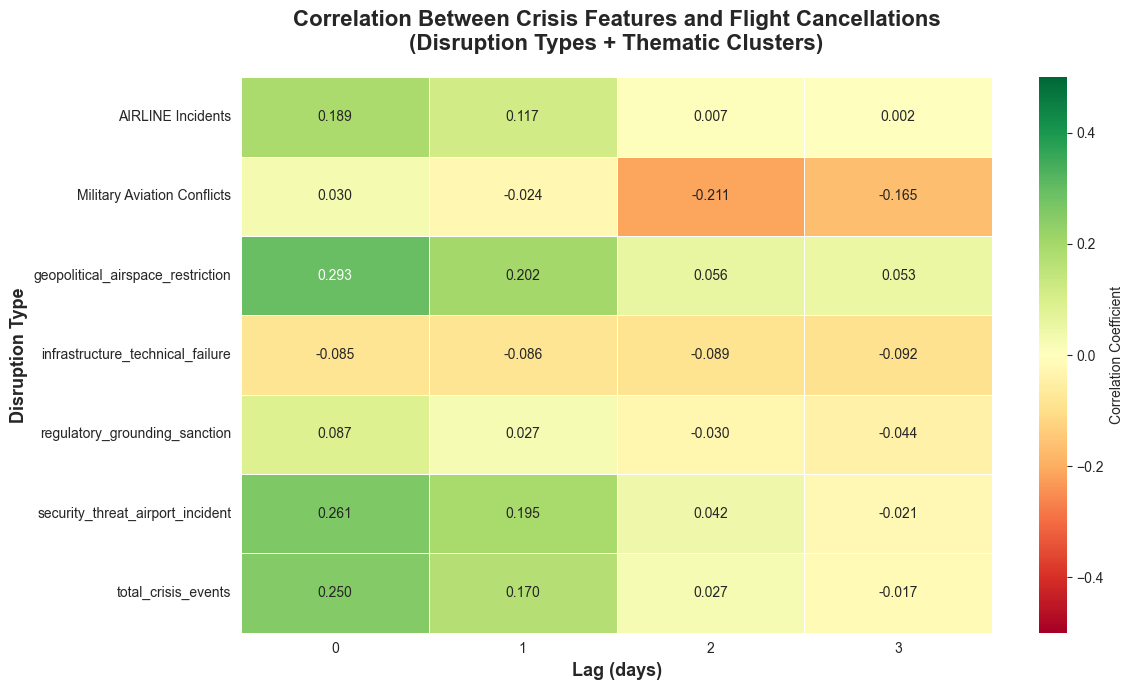

✓ Visualization saved as correlation_heatmap.png
  This single heatmap communicates predictive patterns to stakeholders.


In [25]:
# 3.4 Visualization: Correlation Heatmap

if df_corr is not None and len(df_corr) > 0:
    print(f"\n{'='*80}")
    print("3.4 VISUALIZATION: Correlation Heatmap")
    print(f"{'='*80}")
    print("\nThis visualization communicates the entire predictive landscape:")
    print("  - X-axis: Lag (0, 1, 2, 3 days)")
    print("  - Y-axis: Crisis features (disruption types + thematic clusters)")
    print("  - Color: Correlation strength (red=negative, green=positive)")
    print("  - Annotations: Exact r-values\n")
    
    # Pivot for heatmap (using 'feature' column instead of 'disruption_type')
    corr_pivot = df_corr.pivot(index='feature', columns='lag_days', values='correlation')
    
    # Create figure with better styling
    plt.figure(figsize=(12, max(7, len(corr_pivot) * 0.5)))  # Adjust height based on number of features
    sns.heatmap(corr_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
                vmin=-0.5, vmax=0.5, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Between Crisis Features and Flight Cancellations\n(Disruption Types + Thematic Clusters)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Lag (days)', fontsize=13, fontweight='bold')
    plt.ylabel('Crisis Feature', fontsize=13, fontweight='bold')
    plt.ylabel('Disruption Type', fontsize=13, fontweight='bold')
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Visualization saved as correlation_heatmap.png")
    print("  This single heatmap communicates predictive patterns to stakeholders.")
else:
    print("Skipping visualization - no correlation data available")

---
## OUTPUT FILES GENERATED

This notebook produces the following outputs:

1. **gdelt_crisis_aviation_clean.csv** - Preprocessed crisis events (11K rows)
2. **flight_cancellations_daily_2024.csv** - Daily aggregated flight data (real data)
3. **crisis_events_classified.csv** - Zero-shot classification results
4. **crisis_events_clustered.csv** - Community detection clusters
6. **correlation_analysis.csv** - Lagged correlation statistics
7. **correlation_heatmap.png** - Visualization of correlations

These files support reproducibility and peer review.